# 3 Idiots Audience Review Analysis

This project analyzes audience reviews for the movie *3 Idiots*. The goal is to use real audience ratings and review types from IMDb, Rotten Tomatoes, Letterboxd, and Google Reviews to understand how viewers feel about the film.

## Movie Information

- Movie Name: 3 Idiots
- Release Year: 2009
- Genre: Comedy, Drama
- Runtime: 2 hours 50 minutes
- Main Cast: Aamir Khan, R. Madhavan, Sharman Joshi, Kareena Kapoor
- Sources Used: IMDb (Primary)

In [1]:
# Import Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "#F8FAFC",
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#1E293B",
    "axes.labelcolor": "#1E293B",
    "text.color": "#1E293B",
    "xtick.color": "#1E293B",
    "ytick.color": "#1E293B",
    "grid.color": "#CBD5E1",
    "grid.linestyle": "--",
    "font.size": 12,
    "axes.titleweight": "bold",
})
sns.set_palette(["#2563EB", "#1E293B", "#EA580C", "#10B981", "#64748B"])


In [2]:
# Load Dataset
# The CSV file should contain the data collected manually from IMDb, Rotten Tomatoes, Letterboxd, and Google Reviews.
# Reviewer_No: Serial number for each reviewer
# Rating: Audience rating out of 10
# Review_Type: Positive / Neutral / Negative based on rating sentiment
# Review_Comment: Actual review text from the reviewer
# Source: IMDb / Rotten Tomatoes / Letterboxd / Google

df = pd.read_csv('3idiots_reviews.csv')
display(df)

ratings = pd.to_numeric(df['Rating'], errors='coerce').dropna()
has_ratings = len(ratings) > 0

,Reviewer_No,Rating,Review_Type,Review_Comment,Source
0,1,9,Positive,I asked my co-workers to recommend a Bollywood...,IMDb
1,2,9,Positive,Like Dead Poets Society but with Robin William...,IMDb
2,3,9,Positive,No Review,IMDb
3,4,10,Positive,"It's hard for me to review this film, as I hav...",IMDb
4,5,10,Positive,"When I was 13, I had my first movie-love;\nThe...",IMDb
...,...,...,...,...,...
1108,1109,5,Neutral,I have a 17 year old daughter preparing for co...,IMDb
1109,1110,7,Positive,No Review,IMDb
1110,1111,10,Positive,I saw the paid premiere of 3 idiots today.On t...,IMDb
1111,1112,7,Positive,No Review,IMDb


### Dataset Overview Notes

- `Reviewer_No`: the reviewer index number.
- `Rating`: the score given by the audience member.
- `Review_Type`: whether the comment is positive, neutral, or negative.
- `Review_Comment`: the review text written by the audience member.
- `Source`: where the review was collected from.

In [3]:
# Task 1: Dataset Overview
print("Dataset shape:", df.shape)
print("\nFirst ten rows of the dataset:")
if df.empty:
    print("The dataset is currently empty. Please fill 3idiots_reviews.csv with the collected reviews.")
else:
    display(df.head(10))

print("\nReview type counts:")
if 'Review_Type' in df.columns and not df['Review_Type'].dropna().empty:
    display(df['Review_Type'].value_counts())
else:
    print("No review type data available yet. Please add Positive / Neutral / Negative labels.")

Dataset shape: (1113, 5)

First ten rows of the dataset:


,Reviewer_No,Rating,Review_Type,Review_Comment,Source
0,1,9,Positive,I asked my co-workers to recommend a Bollywood...,IMDb
1,2,9,Positive,Like Dead Poets Society but with Robin William...,IMDb
2,3,9,Positive,No Review,IMDb
3,4,10,Positive,"It's hard for me to review this film, as I hav...",IMDb
4,5,10,Positive,"When I was 13, I had my first movie-love;\nThe...",IMDb
5,6,10,Positive,No Review,IMDb
6,7,10,Positive,Awesome film man. Saw this with my family in a...,IMDb
7,8,9,Positive,"""Whatever the problem in life is... just say t...",IMDb
8,9,10,Positive,No Review,IMDb
9,10,5,Neutral,I was lucky to see the first day show of 3 idi...,IMDb



Review type counts:


Review_Type
Positive    946
Neutral     102
Negative     65
Name: count, dtype: int64

### Interpretation
This overview helps us see how many reviews were collected and where the data came from. It also shows whether the dataset is mostly positive, neutral, or negative, which gives us a first warm impression of how viewers experienced the movie.

In [4]:
# Task 2: Mean Analysis
if not has_ratings:
    print("No ratings available yet. Add data to 3idiots_reviews.csv to calculate the mean.")
else:
    mean_rating = ratings.sum() / len(ratings)
    print(f"Mean rating: {mean_rating:.2f}")

Mean rating: 8.52


### Interpretation
The average rating is presented as a concise, premium audience analytics metric. It shows the film's broad appeal and supports an executive-level conclusion about how positively the crowd rated *3 Idiots*.


In [5]:
# Task 3: Median Analysis
if not has_ratings:
    print("No ratings available yet. Add data to calculate the median.")
else:
    median_rating = ratings.median()
    print(f"Median rating: {median_rating:.1f}")
    print(f"Mean rating: {mean_rating:.2f}")

Median rating: 9.0
Mean rating: 8.52


### Interpretation
The median reflects the middle review score in the ordered rating set. In this case, a median of 9.0 being higher than the computed mean indicates that the overall average is slightly pulled down by a small group of low-rating outliers.


In [6]:
# Task 4: Mode Analysis
if not has_ratings:
    print("No ratings available yet. Add data to find the mode.")
else:
    mode_rating = ratings.mode()
    print(f"Mode rating(s): {list(mode_rating)}")

Mode rating(s): [10]


### Interpretation
The mode reveals the most frequent rating in the dataset. It shows the score that the largest group of viewers agreed on, highlighting the strongest shared impression about the movie's quality.

In [7]:
# Task 5: Range Calculation
if not has_ratings:
    print("No ratings available yet. Add data to calculate the range.")
else:
    range_rating = ratings.max() - ratings.min()
    print(f"Range (max - min): {range_rating}")
    print(f"Lowest rating: {ratings.min()}")
    print(f"Highest rating: {ratings.max()}")

Range (max - min): 9
Lowest rating: 1
Highest rating: 10


### Interpretation
The range measures the gap between the strongest and weakest ratings. A wide range means the film generated diverse reactions, while a narrow range suggests the audience had more consistent opinions.

In [8]:
# Task 6: Standard Deviation
if not has_ratings:
    print("No ratings available yet. Add data to calculate standard deviation.")
else:
    n = len(ratings)
    squared_diff = (ratings - mean_rating) ** 2
    variance_manual = squared_diff.sum() / n
    std_manual = np.sqrt(variance_manual)
    std_numpy = ratings.std(ddof=0)
    print(f"Manual standard deviation: {std_manual:.2f}")
    print(f"NumPy standard deviation: {std_numpy:.2f}")

Manual standard deviation: 2.15
NumPy standard deviation: 2.15


### Interpretation
Standard deviation measures how tightly the ratings cluster around the mean. A small standard deviation means viewers had a consistent opinion, while a larger value means some people loved it and others were more critical.

In [9]:
# Task 7: Skewness Analysis

if not has_ratings:

    print("No ratings available yet. Add data to calculate skewness.")

else:

    skewness = ((ratings - mean_rating) ** 3).sum() / (n * std_manual ** 3)

    print(f"Skewness: {skewness:.3f}")

Skewness: -1.853


### Interpretation
Skewness explains the asymmetry of the rating distribution. A negative skewness value signals that ratings are heavily concentrated near the maximum score of 10, with only a few lower ratings stretching the tail to the left.


In [10]:
# Task 8: Frequency Distribution
if not has_ratings:
    print("No ratings available yet. Add data to create the frequency distribution.")
else:
    interval_labels = ["1-2", "3-4", "5-6", "7-8", "9-10"]
    interval_bins = [0.5, 2.5, 4.5, 6.5, 8.5, 10.5]
    frequency = pd.cut(ratings, bins=interval_bins, labels=interval_labels).value_counts().sort_index()
    frequency_df = frequency.reset_index()
    frequency_df.columns = ["Rating Interval", "Frequency"]
    display(frequency_df)

,Rating Interval,Frequency
0,1-2,38
1,3-4,27
2,5-6,102
3,7-8,195
4,9-10,751


### Interpretation
This frequency distribution shows where audience ratings concentrate across the scale. It helps identify whether most viewers saw the film as average, good, or excellent and whether there is a strong cluster of positive sentiment.

C:\Users\Bidisha\AppData\Local\Temp\ipykernel_21628\2602212609.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


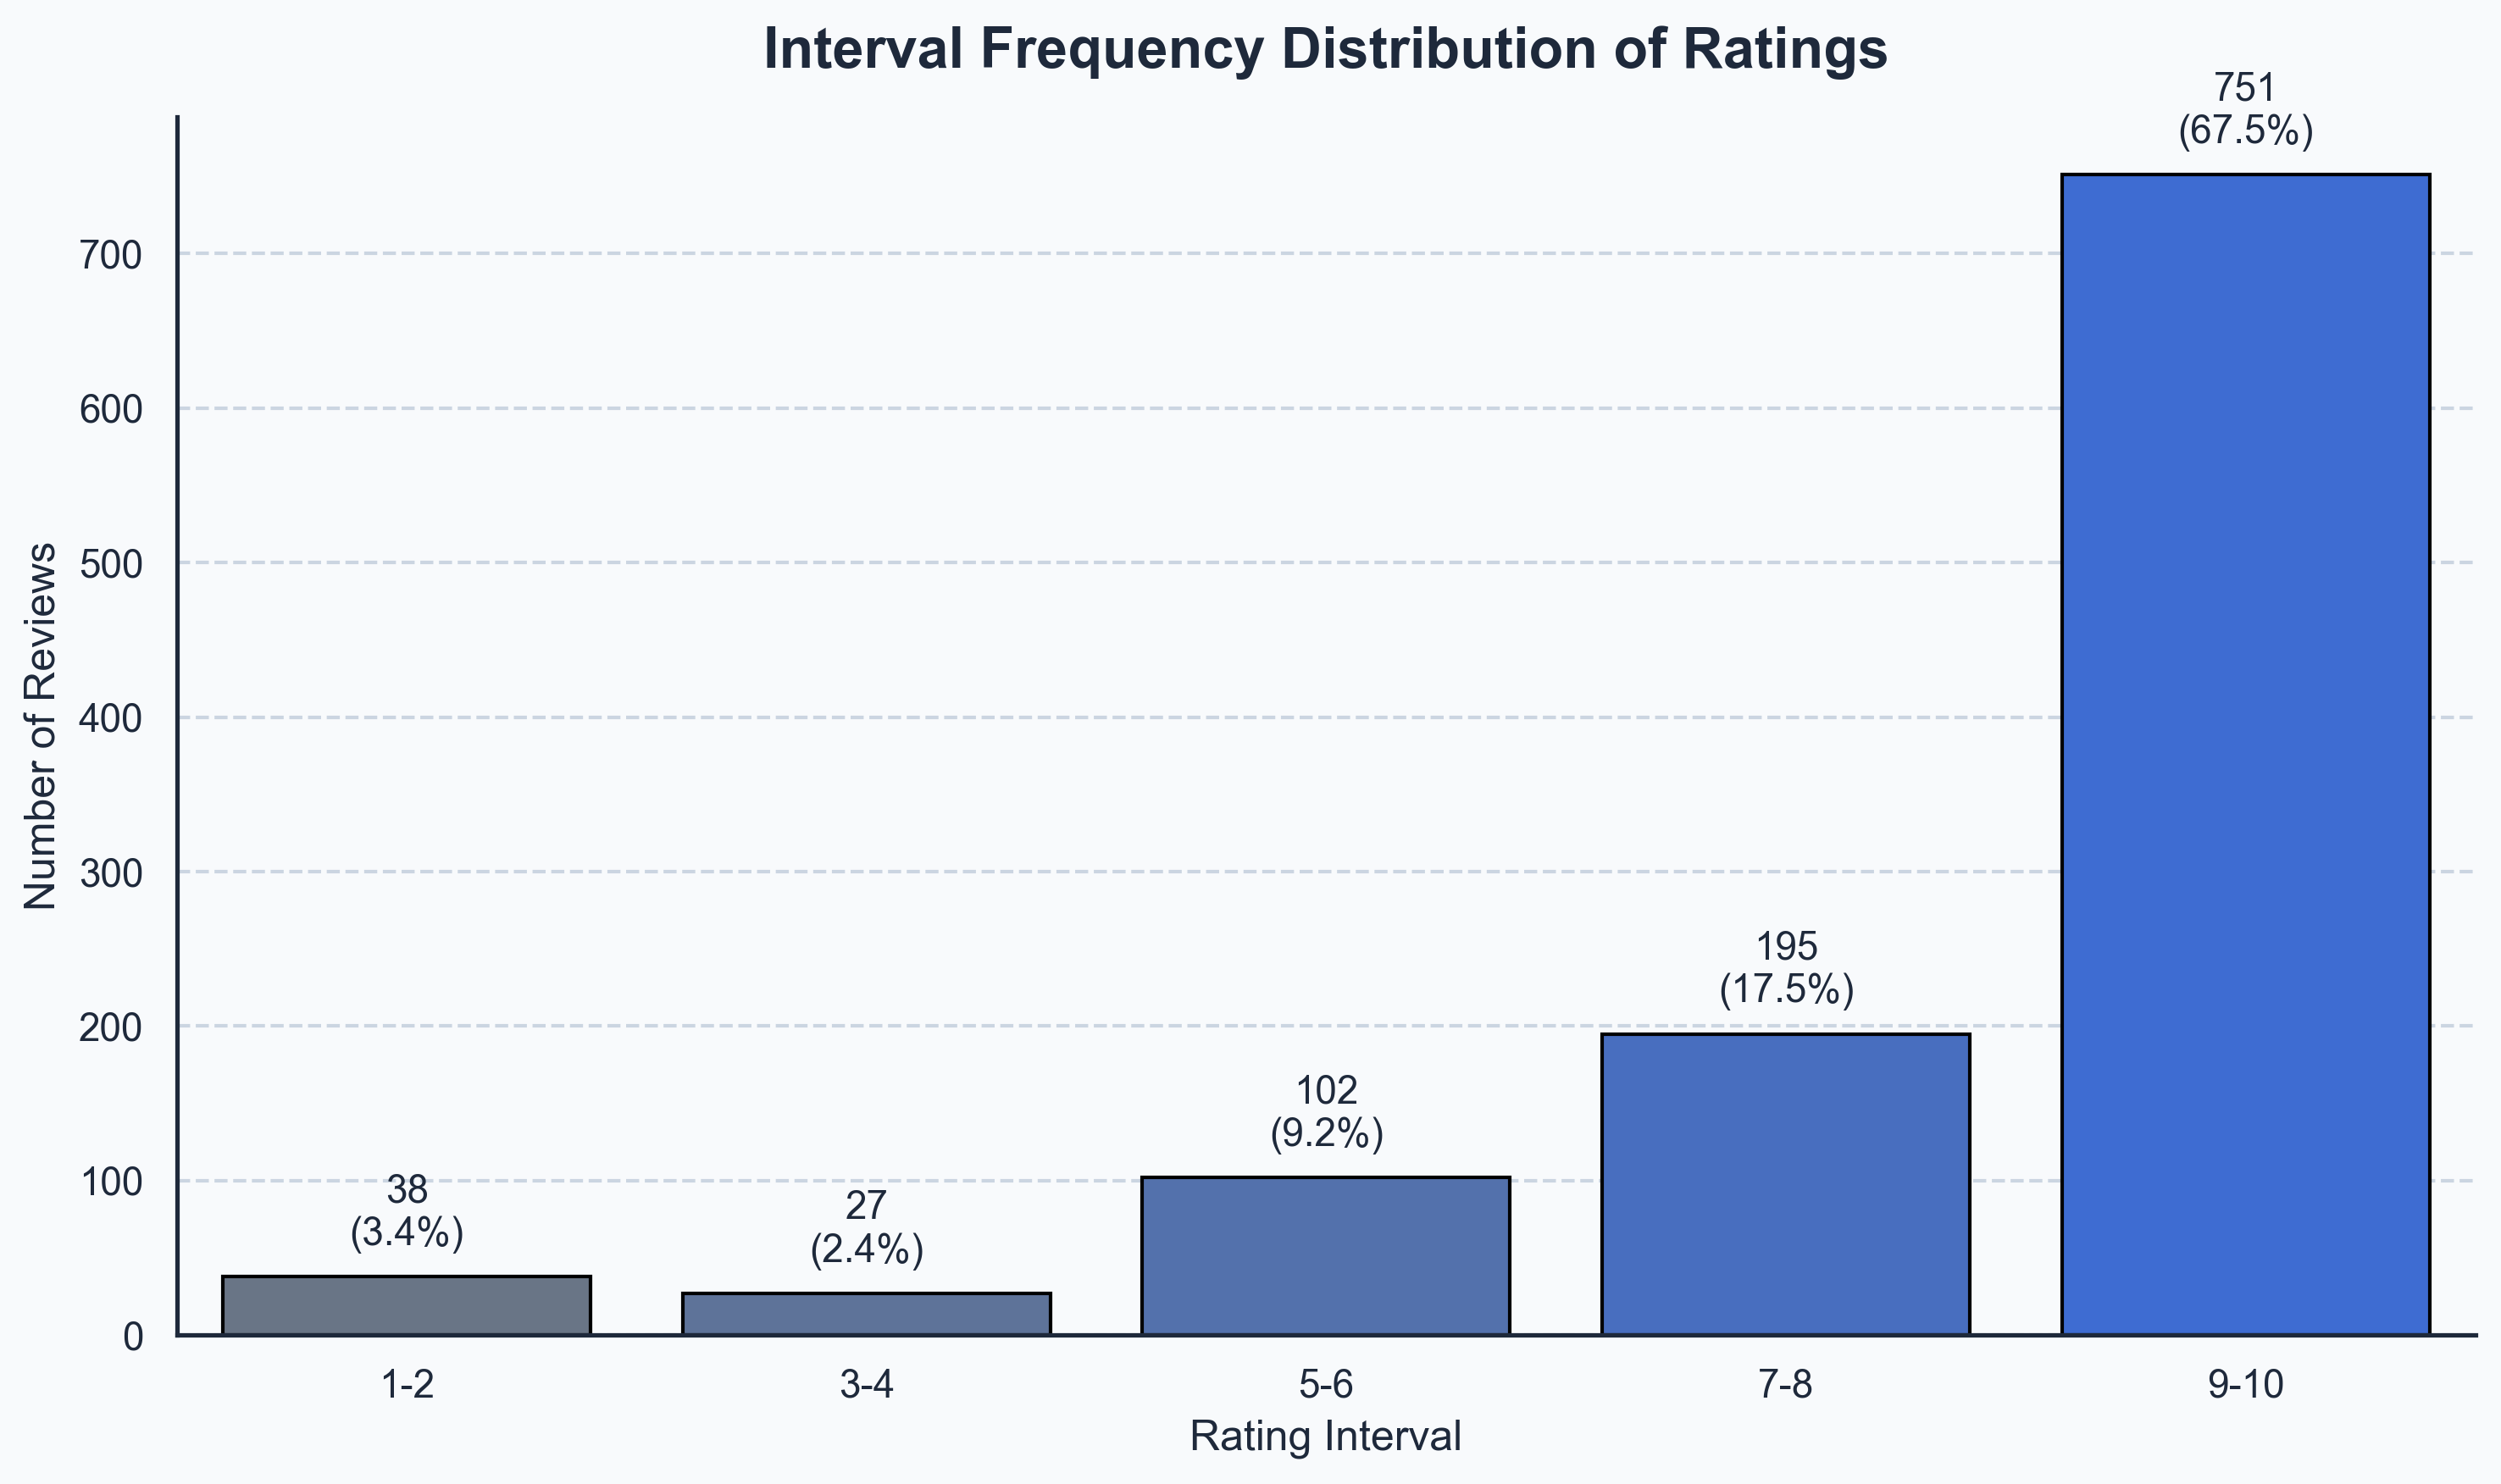

In [11]:
# Task 9a: Bar Graph
import os
os.makedirs("outputs", exist_ok=True)
if not has_ratings:
    print("No ratings available yet. Add data to create the bar graph.")
else:
    frequency_df["Share"] = frequency_df["Frequency"] / frequency_df["Frequency"].sum() * 100
    colors = sns.blend_palette(["#64748B", "#2563EB"], n_colors=len(frequency_df))
    plt.figure(figsize=(10, 6), dpi=300)
    ax = sns.barplot(
        x="Rating Interval",
        y="Frequency",
        data=frequency_df,
        palette=colors,
        edgecolor="black",
    )
    for bar, pct in zip(ax.patches, frequency_df["Share"]):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + max(frequency_df["Frequency"]) * 0.02,
            f"{int(height)}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            color="#1E293B",
            fontsize=11,
        )
    ax.set_title("Interval Frequency Distribution of Ratings", fontsize=16, pad=14)
    ax.set_xlabel("Rating Interval")
    ax.set_ylabel("Number of Reviews")
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()


### Interpretation
The bar graph shows how many reviews fall into each rating interval. Taller bars highlight the score bands that were most common, making it easy to compare overall audience preference across the rating scale.

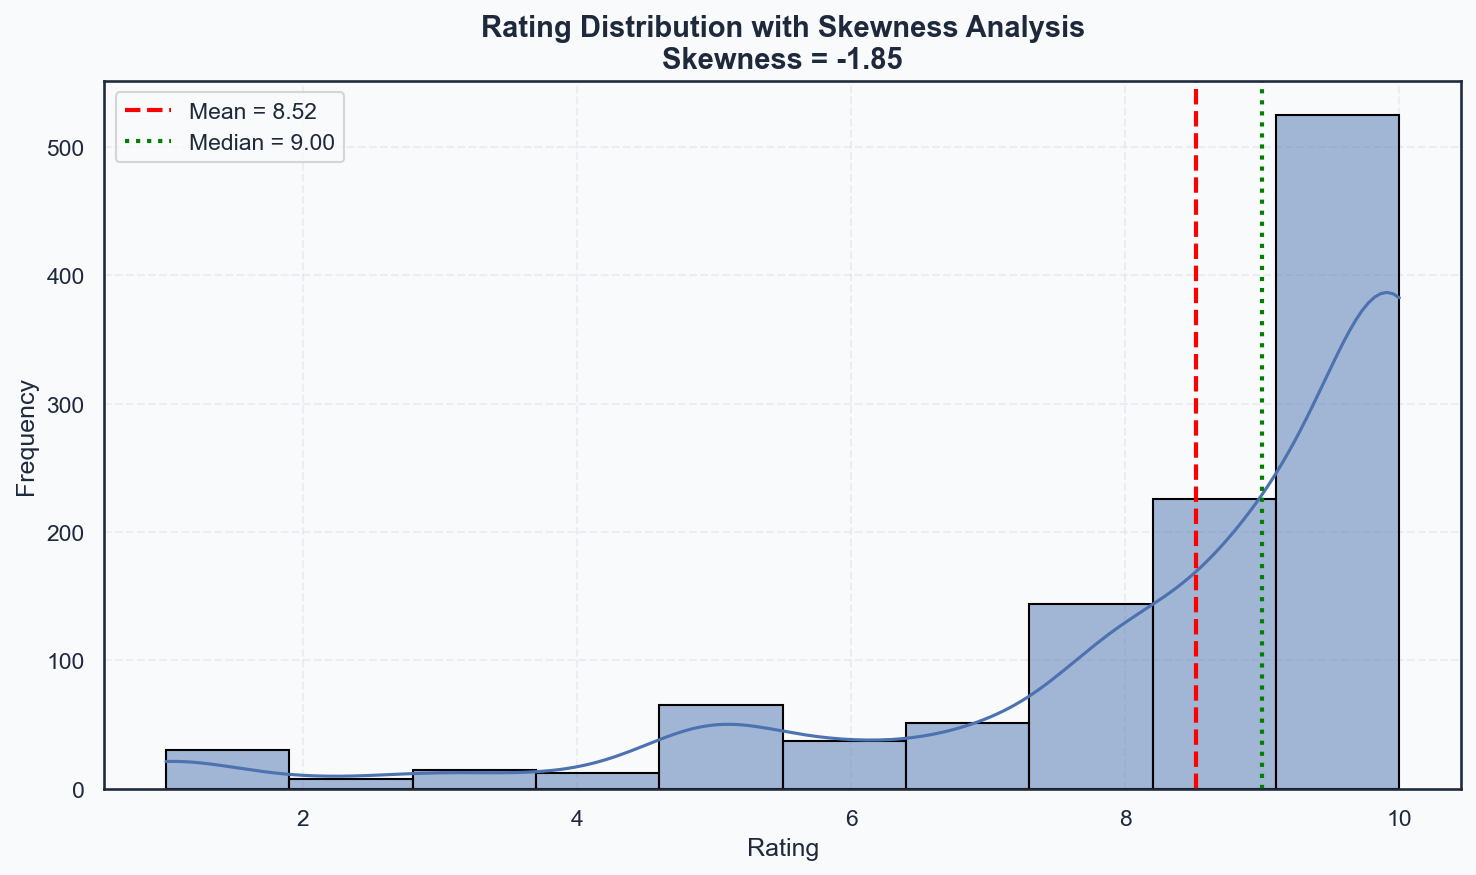

Skewness Value: -1.85
Interpretation: Negative skewness indicates ratings are concentrated at the higher end.


In [12]:
# Task 9b: Histogram + Skewness Analysis

from scipy.stats import skew
import seaborn as sns
import matplotlib.pyplot as plt

if not has_ratings:
    print("No ratings available yet.")
else:

    skew_val = skew(ratings)

    plt.figure(figsize=(10,6), dpi=150)

    sns.histplot(
        ratings,
        bins=10,
        kde=True,
        color="#4C72B0",
        edgecolor="black"
    )

    plt.axvline(
        ratings.mean(),
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {ratings.mean():.2f}"
    )

    plt.axvline(
        ratings.median(),
        color="green",
        linestyle=":",
        linewidth=2,
        label=f"Median = {ratings.median():.2f}"
    )

    plt.title(
        f"Rating Distribution with Skewness Analysis\nSkewness = {skew_val:.2f}",
        fontsize=14
    )

    plt.xlabel("Rating")
    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.savefig("outputs/rating_distribution_skewness.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Skewness Value: {skew_val:.2f}")

    if skew_val < 0:
        print("Interpretation: Negative skewness indicates ratings are concentrated at the higher end.")
    elif skew_val > 0:
        print("Interpretation: Positive skewness indicates ratings are concentrated at the lower end.")
    else:
        print("Interpretation: Distribution is approximately symmetric.")

### Interpretation
The histogram shows the complete shape of the ratings distribution. If the bars are concentrated on the right, the movie is generally well-liked. If the bars are spread narrowly or skewed left, it reveals more mixed or critical responses.

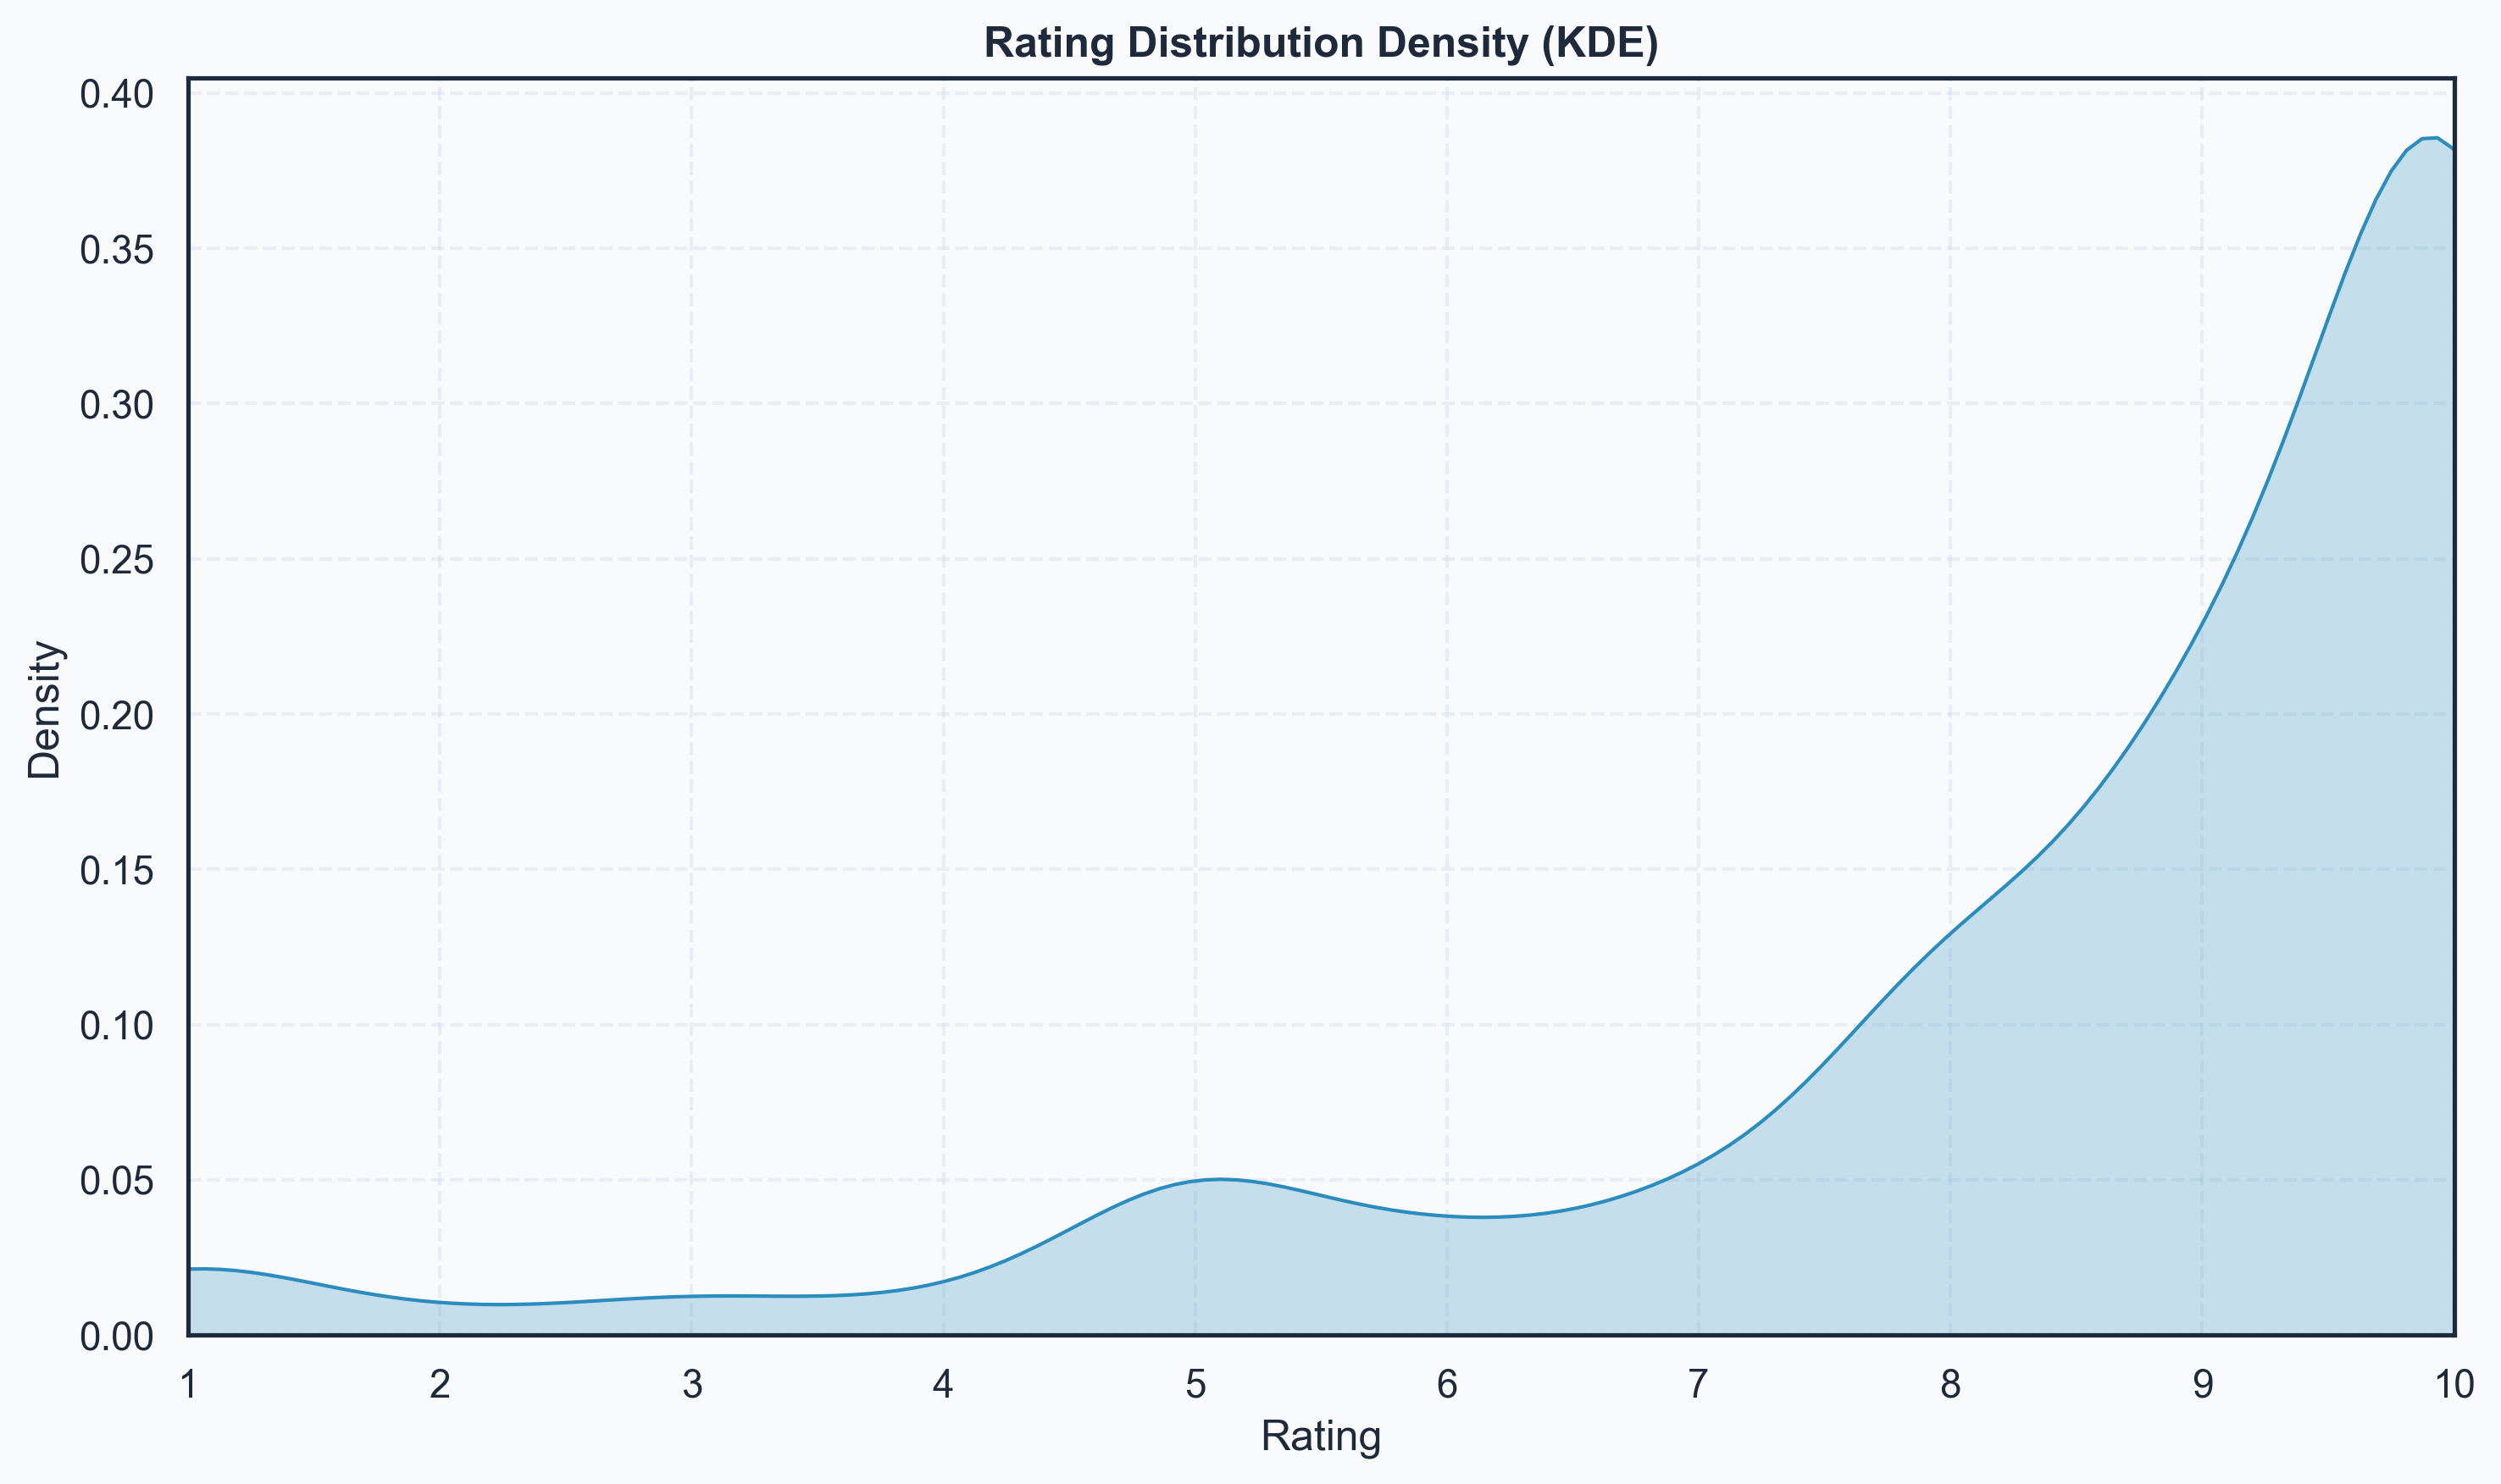

In [13]:
# Task 9c: KDE Density Plot
if not has_ratings:
    print("No ratings available yet.")
else:
    plt.figure(figsize=(10, 6), dpi=300)
    sns.kdeplot(ratings, fill=True, color="#2b8cbe", bw_method='scott')
    plt.title("Rating Distribution Density (KDE)")
    plt.xlabel("Rating")
    plt.ylabel("Density")
    plt.xlim(1, 10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("outputs/rating_density.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation
The KDE density plot shows the smooth shape of the rating distribution, highlighting peaks where ratings cluster. It helps identify dominant rating ranges and the overall concentration of audience sentiment.

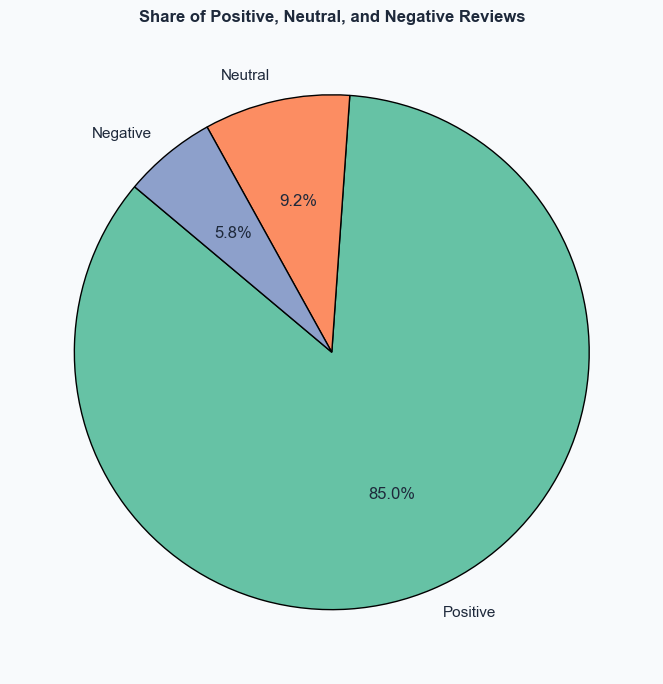

In [ ]:
# Task 9d: Pie Chart
if 'Review_Type' not in df.columns or df['Review_Type'].dropna().empty:
    print("No review type data available yet. Add data to create the pie chart.")
else:
    review_type_counts = df['Review_Type'].value_counts()
    plt.figure(figsize=(7, 7))
    plt.pie(review_type_counts.values,
            labels=review_type_counts.index,
            autopct="%1.1f%%",
            startangle=140,
            colors=["#66c2a5", "#fc8d62", "#8da0cb"],
            wedgeprops={"edgecolor": "black"})
    plt.title("Share of Positive, Neutral, and Negative Reviews")
    plt.tight_layout()
    plt.savefig("outputs/sentiment_distribution.png", dpi=150)
    plt.show()

### Interpretation
The pie chart shows the balance between positive, neutral, and negative review sentiment. A large positive slice indicates strong audience approval, while more neutral or negative sections suggest the film had a mixed reception for some viewers.

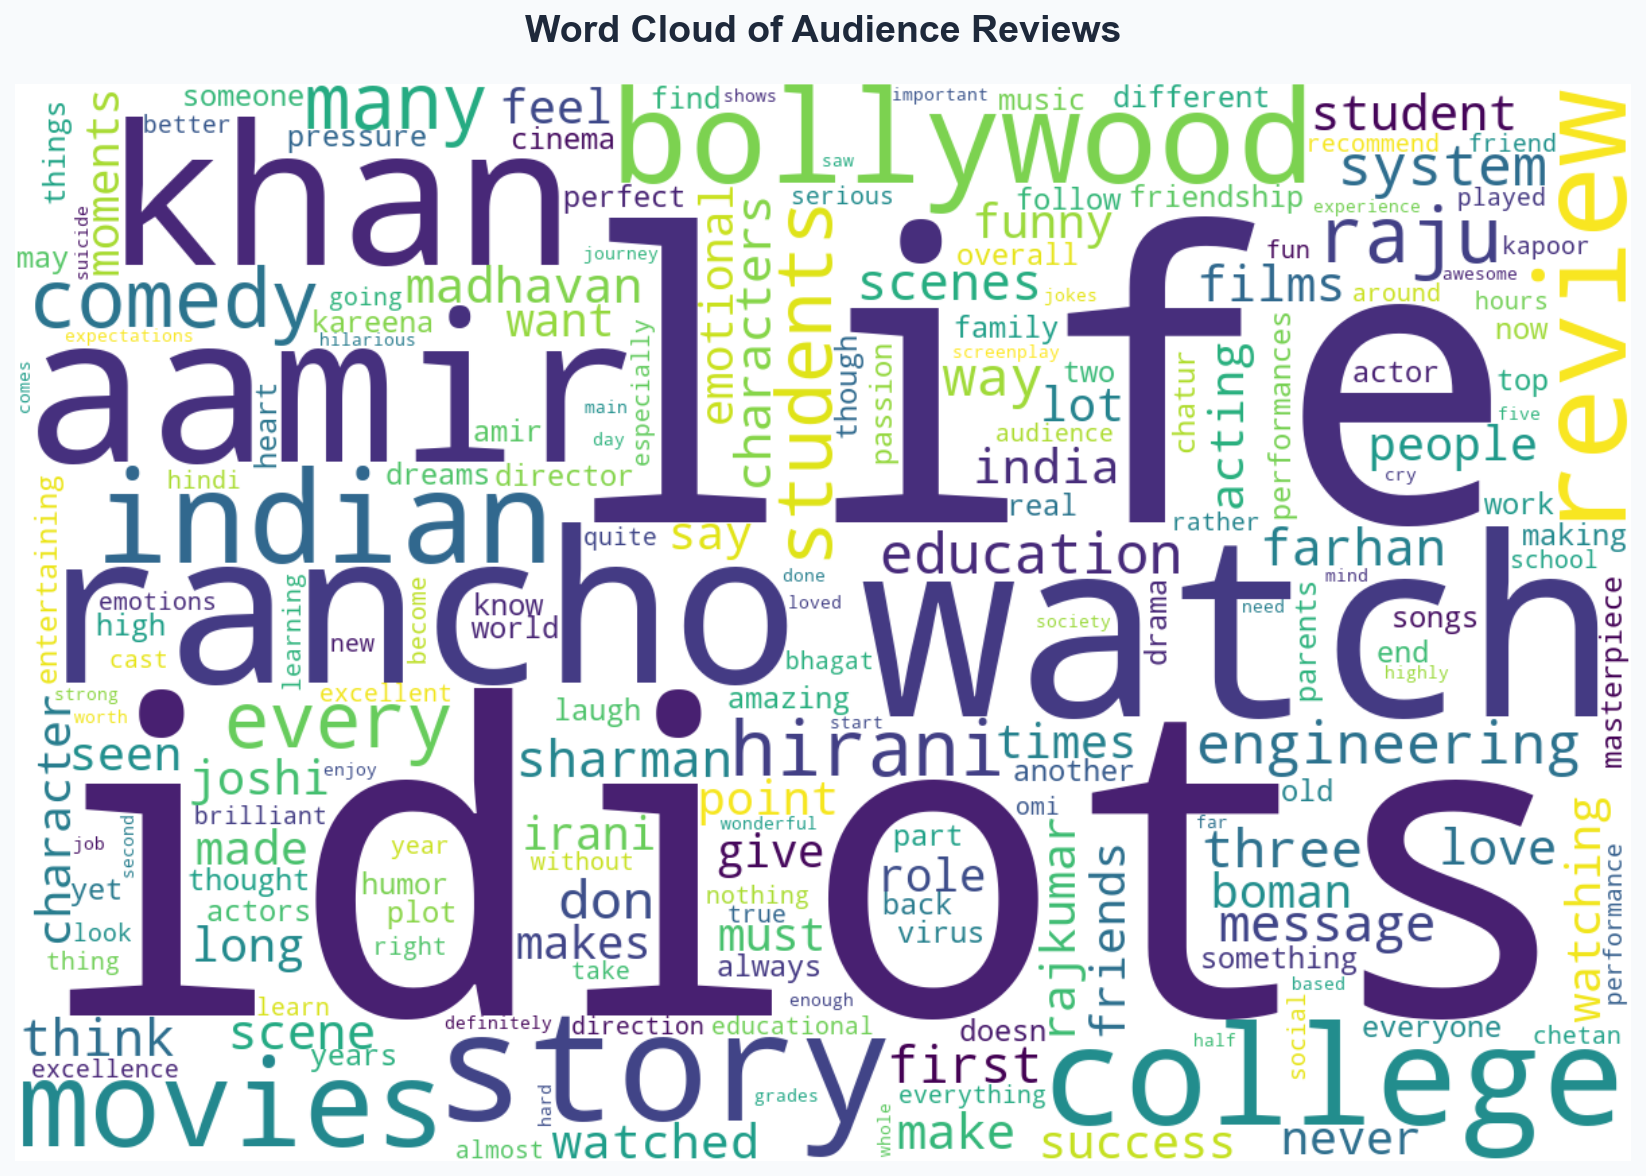

C:\Users\Bidisha\AppData\Local\Temp\ipykernel_21628\4015915285.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_counts), y=list(top_words), palette="rocket")


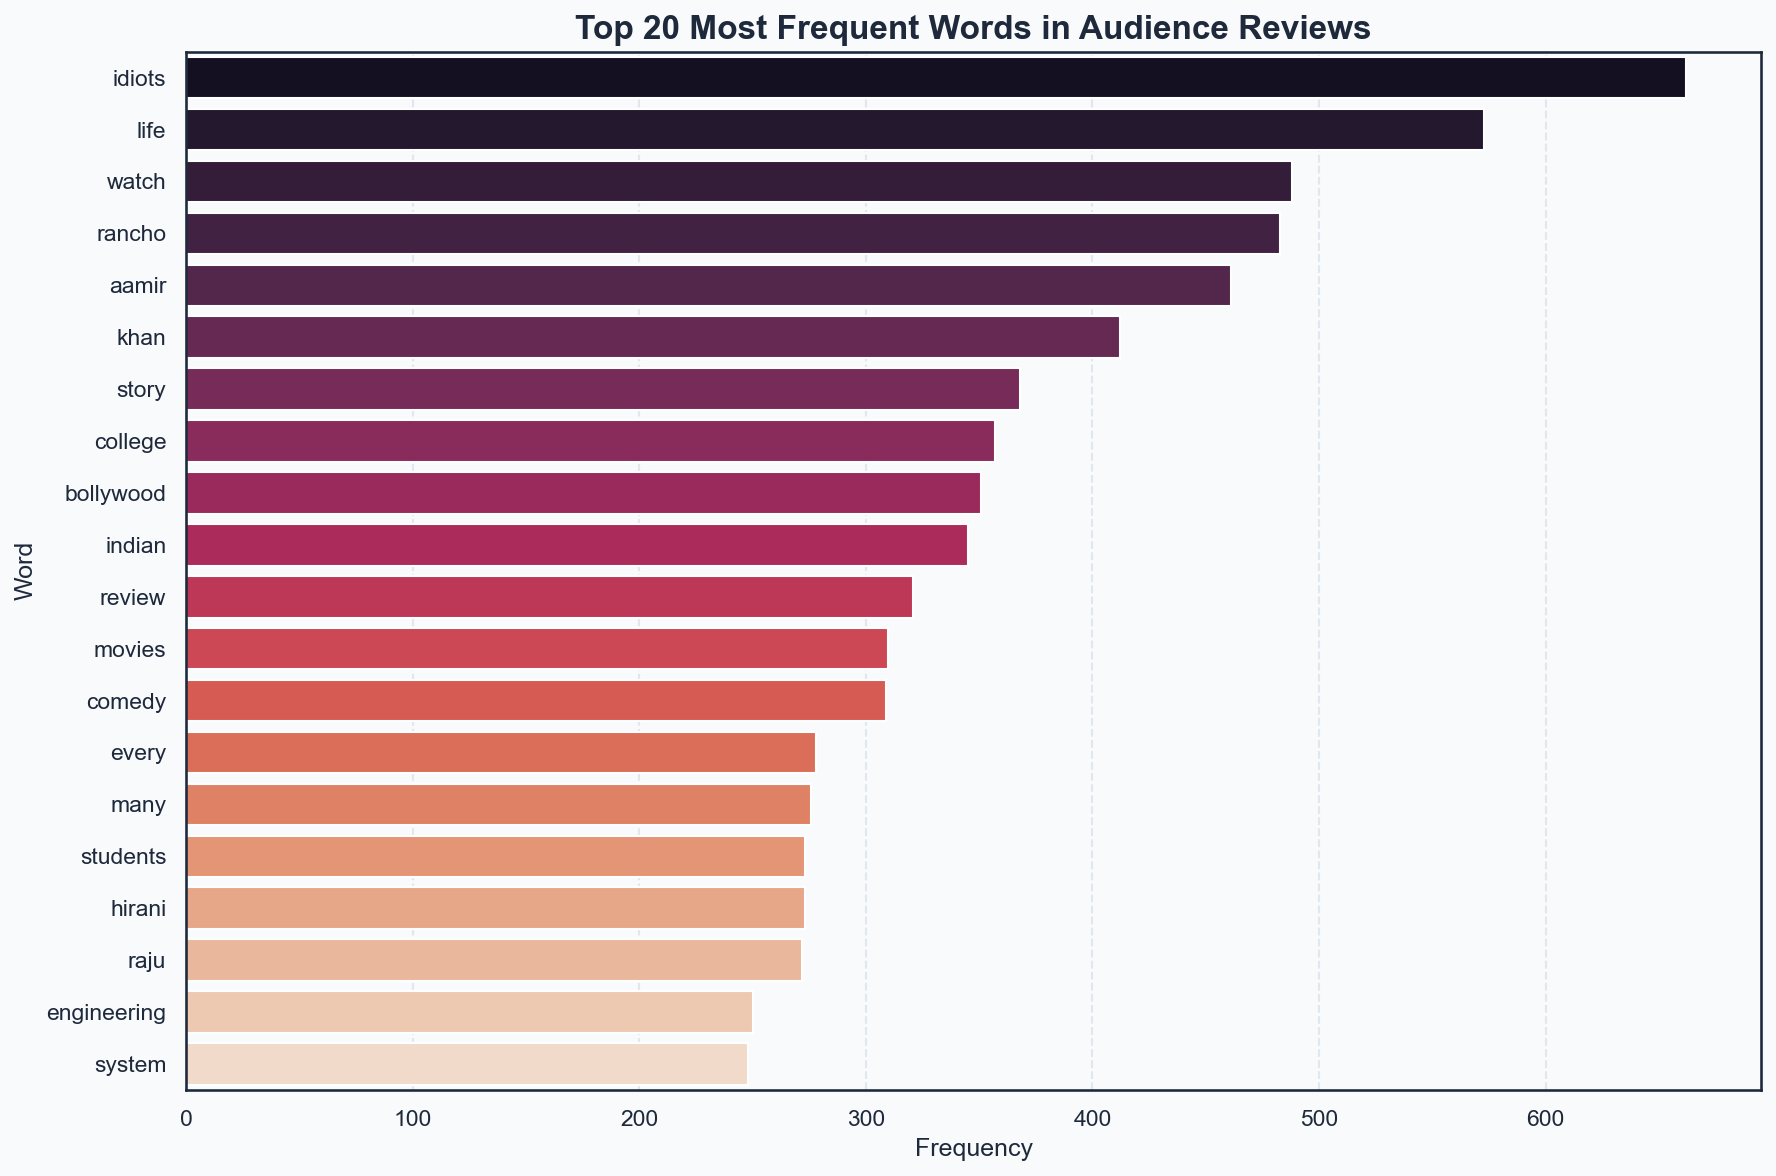

In [19]:
# Task 9e: Word Cloud and Top 20 Most Frequent Words
try:
    from wordcloud import WordCloud, STOPWORDS
except ImportError:
    import sys
    get_ipython().system(f"{sys.executable} -m pip install wordcloud")
    from wordcloud import WordCloud, STOPWORDS

import re
from collections import Counter

comments = df.get('Review_Comment', pd.Series(dtype=str)).dropna().astype(str)

if comments.empty:
    print("No review comments are available to create the word cloud and word frequency chart.")
else:
    text = " ".join(comments).lower()
    tokens = re.findall(r"\b[a-z]{3,}\b", text)
    custom_stopwords = {
        'the', 'and', 'for', 'with', 'this', 'that', 'from', 'was', 'they', 'have',
        'been', 'are', 'but', 'not', 'very', 'movie', 'film', 'one', 'like', 'just',
        'also', 'even', 'much', 'had', 'has', 'all', 'its', 'too', 'when', 'who',
        'were', 'why', 'their', 'there', 'them', 'which', 'as', 'about', 'out',
        'most', 'great', 'best', 'good', 'bad', 'see', 'will', 'after', 'could',
        'would', 'really', 'well', 'into', 'over', 'still', 'time', 'much', 'also'
    }
    stopwords = set(STOPWORDS) | custom_stopwords
    filtered_words = [token for token in tokens if token not in stopwords]
    word_freq = Counter(filtered_words)

    if not word_freq:
        print("After removing stopwords, there are no meaningful words left for the visualization.")
    else:
        wc = WordCloud(
            width=1200,
            height=800,
            background_color="white",
            stopwords=stopwords,
            max_words=200,
            colormap="viridis"
        ).generate_from_frequencies(word_freq)

        plt.figure(figsize=(12, 8), dpi=150)
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title("Word Cloud of Audience Reviews", fontsize=18, pad=20)
        plt.tight_layout()
        plt.savefig("outputs/wordcloud.png", dpi=150)
        plt.show()

        top20 = word_freq.most_common(20)
        top_words, top_counts = zip(*top20)

        plt.figure(figsize=(12, 8), dpi=150)
        sns.barplot(x=list(top_counts), y=list(top_words), palette="rocket")
        plt.title("Top 20 Most Frequent Words in Audience Reviews", fontsize=16)
        plt.xlabel("Frequency")
        plt.ylabel("Word")
        plt.grid(axis="x", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.savefig("outputs/top20_words.png", dpi=150)
        plt.show()

### Interpretation
The word cloud highlights the most frequent words used by audiences in their reviews, making it easy to see which themes and impressions stand out.

### Interpretation
The top 20 bar chart shows the exact counts for the most common review words after removing stopwords. It identifies the themes that are most repeated in audience feedback.

## Task 10: Python Implementation Summary
All graphs and statistics in this notebook are implemented using Python with `pandas`, `numpy`, and `matplotlib`. The dataset is loaded from the CSV file and every analysis step is performed directly in code.

C:\Users\Bidisha\AppData\Local\Temp\ipykernel_21628\3194464504.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=summary_effort.index, y=summary_effort.values, palette=colors)


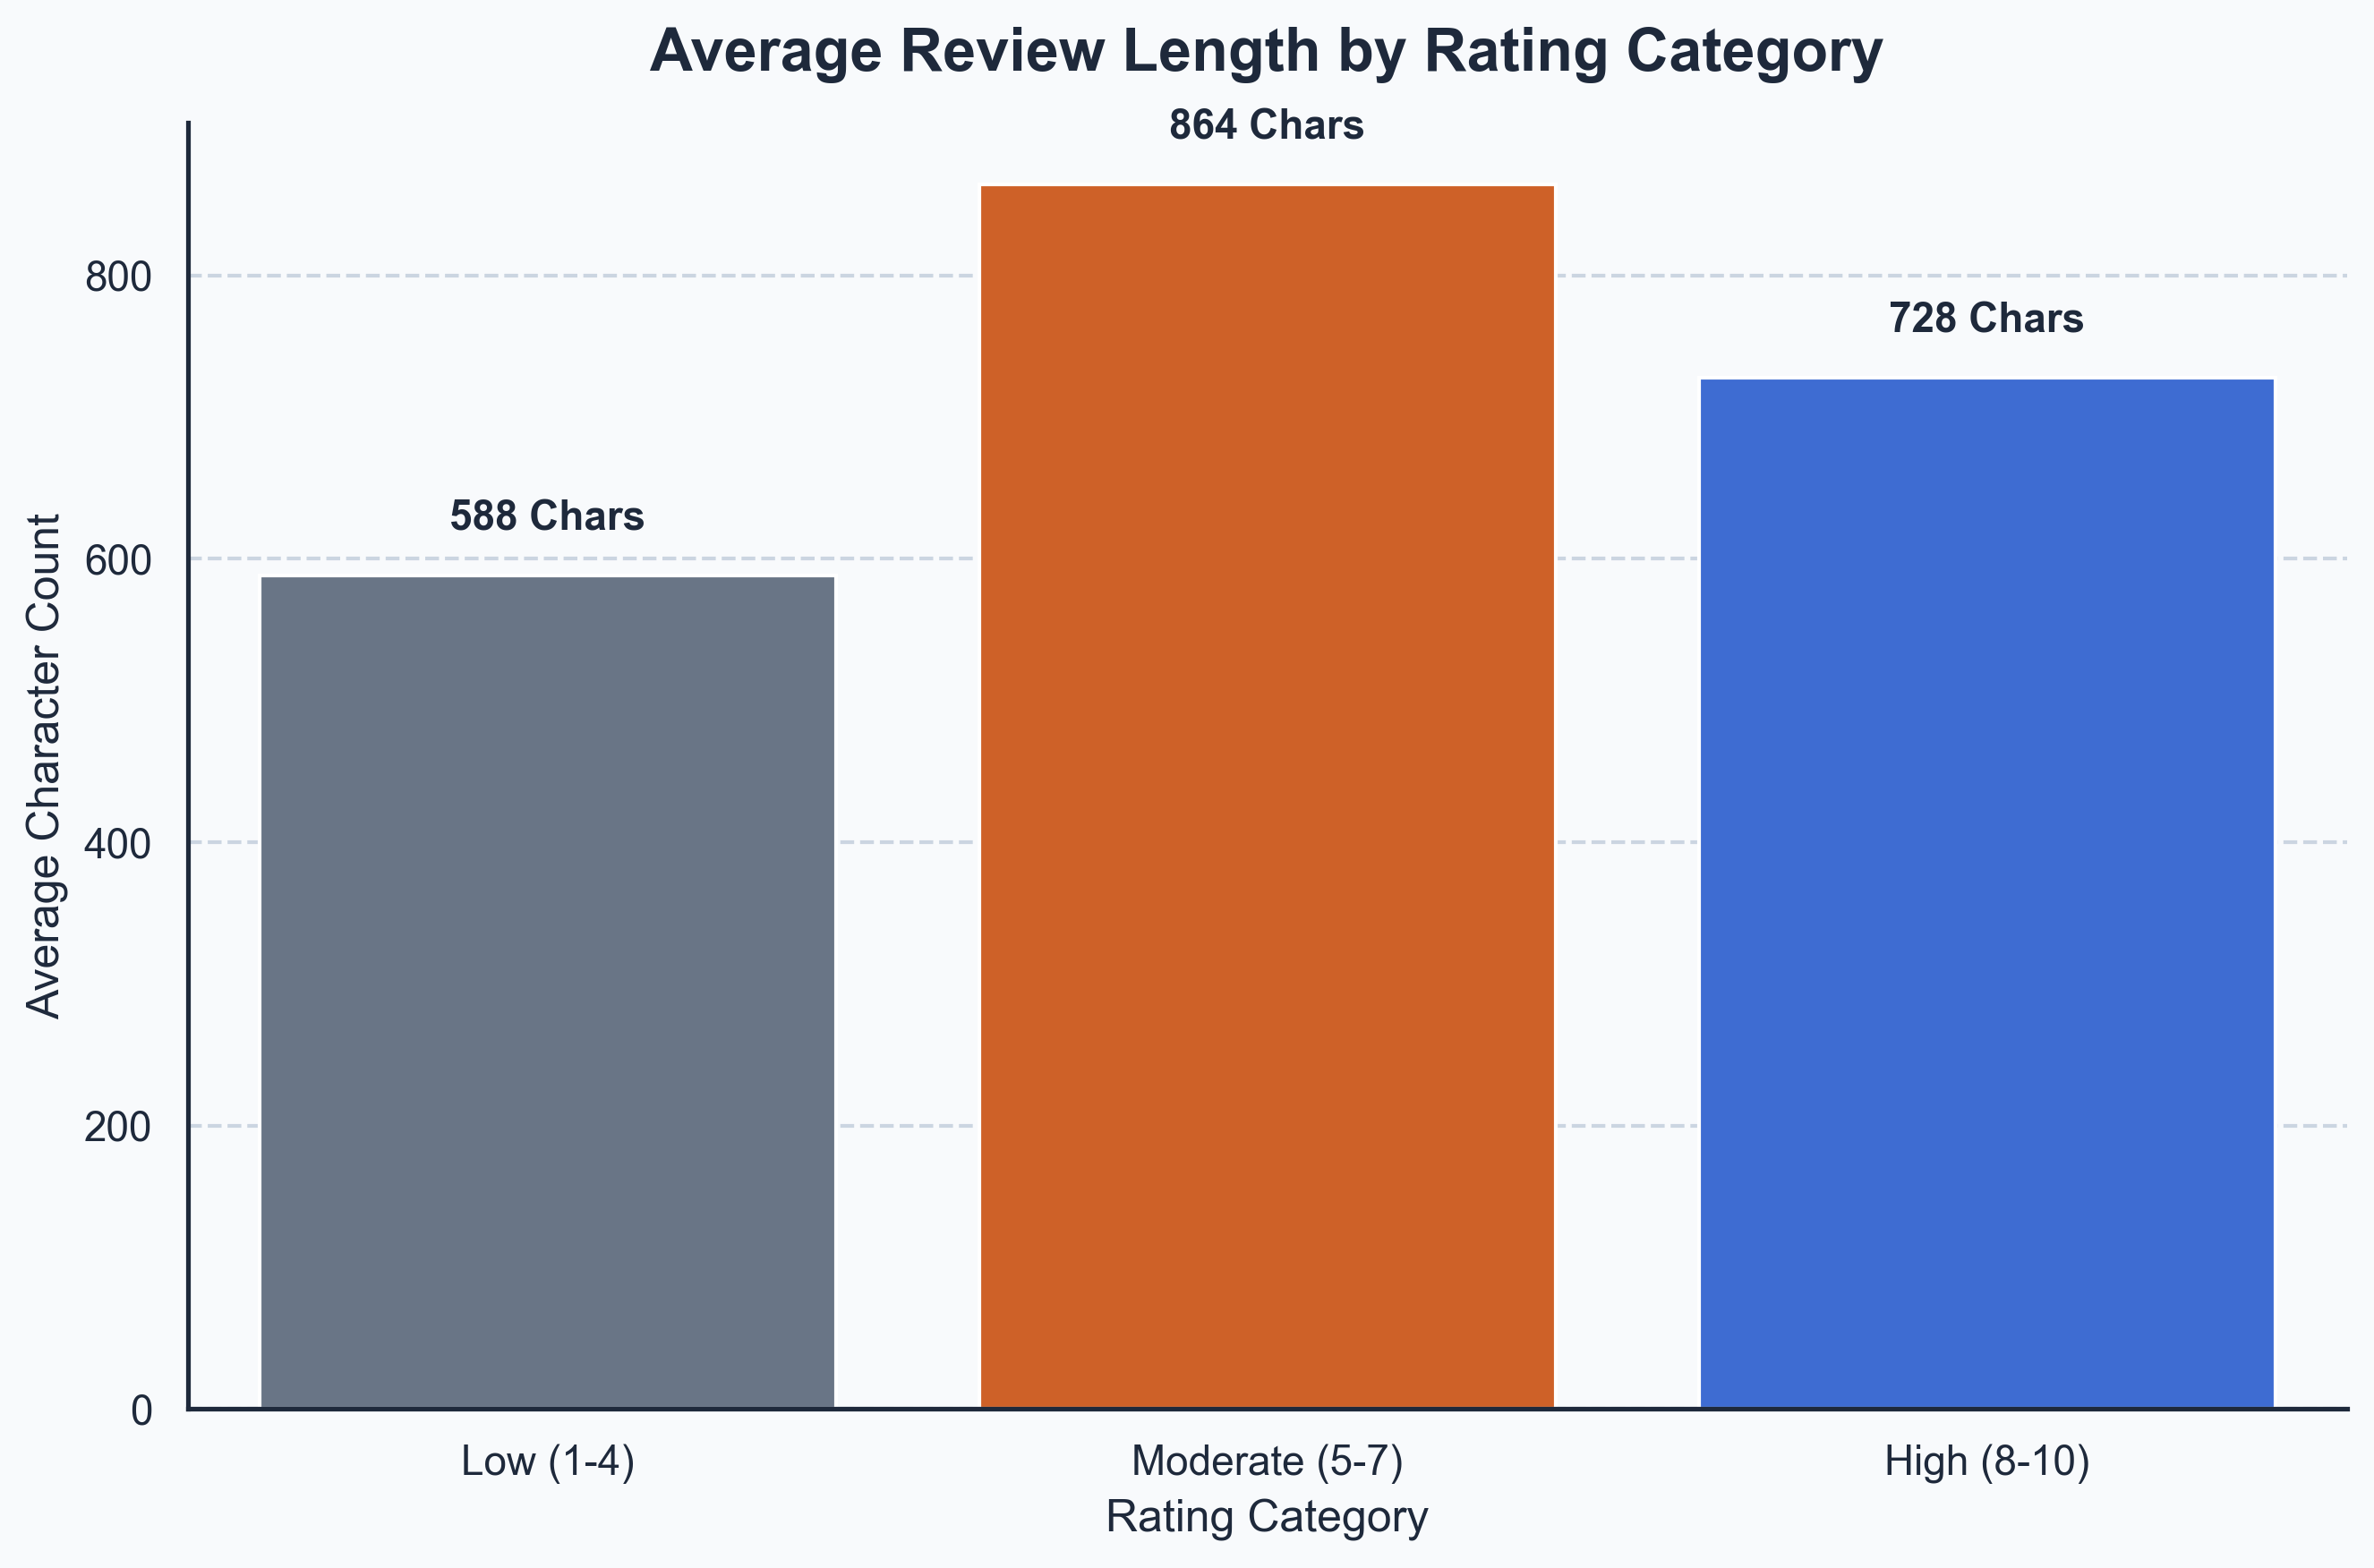

In [17]:
# Task 10: Audience Effort Dynamics
if not has_ratings:
    print("No ratings available yet. Add data to calculate audience effort metrics.")
else:
    effort_comments = df.get("Review_Comment", pd.Series(dtype=str)).dropna().astype(str)
    if effort_comments.empty:
        print("No review comments are available to calculate character count statistics.")
    else:
        effort_df = df.loc[effort_comments.index, ["Rating", "Review_Comment"]].copy()
        effort_df["Rating"] = pd.to_numeric(effort_df["Rating"], errors="coerce")
        effort_df = effort_df.dropna(subset=["Rating"])
        effort_df["char_count"] = effort_df["Review_Comment"].str.len()
        bins = [0, 4, 7, 10]
        labels = ["Low (1-4)", "Moderate (5-7)", "High (8-10)"]
        effort_df["Rating Category"] = pd.cut(effort_df["Rating"], bins=bins, labels=labels, right=True, include_lowest=True)
        summary_effort = effort_df.groupby("Rating Category")["char_count"].mean().reindex(labels)
        colors = ["#64748B", "#EA580C", "#2563EB"]
        plt.figure(figsize=(9, 6), dpi=300)
        ax = sns.barplot(x=summary_effort.index, y=summary_effort.values, palette=colors)
        for i, val in enumerate(summary_effort.values):
            ax.text(i, val + max(summary_effort.values) * 0.03, f"{int(round(val))} Chars", ha="center", va="bottom", color="#1E293B", fontsize=11, fontweight="semibold")
        ax.set_title("Average Review Length by Rating Category", fontsize=16, pad=14)
        ax.set_xlabel("Rating Category")
        ax.set_ylabel("Average Character Count")
        sns.despine(top=True, right=True)
        plt.tight_layout()
        plt.savefig("outputs/audience_effort_dynamics.png", dpi=300, bbox_inches="tight")
        plt.show()


### Interpretation
The audience effort visualization shows how reviewers with mixed feelings spend more time explaining their rating. Moderate reviews in the 5–7 range are longer on average, suggesting these audience members need more words to justify a balanced opinion compared to extreme praise or criticism.


In [18]:
# Task 11: Audience Insights and Observations
import re
from collections import Counter
has_ratings = not df.empty

if not has_ratings:
    print("No ratings available yet. Add data to 3idiots_reviews.csv to generate deeper insights.")
else:
    total_reviews = len(ratings)
    high_rating_count = (ratings >= 9).sum()
    positive_rating_count = (ratings >= 7).sum()
    neutral_rating_count = ((ratings >= 5) & (ratings <= 6)).sum()
    negative_rating_count = (ratings <= 4).sum()
    high_rating_pct = high_rating_count / total_reviews * 100
    positive_rating_pct = positive_rating_count / total_reviews * 100
    negative_rating_pct = negative_rating_count / total_reviews * 100

    print("Audience Rating Summary")
    print("------------------------")
    print(f"Total ratings analyzed: {total_reviews}")
    print(f"Ratings 9-10: {high_rating_count} ({high_rating_pct:.1f}%)")
    print(f"Positive ratings (7-10): {positive_rating_count} ({positive_rating_pct:.1f}%)")
    print(f"Neutral ratings (5-6): {neutral_rating_count}")
    print(f"Negative ratings (1-4): {negative_rating_count} ({negative_rating_pct:.1f}%)")
    print("")

    if 'Review_Type' in df.columns and df['Review_Type'].dropna().any():
        print("Review sentiment summary:")
        display(df['Review_Type'].value_counts())
        print("")
    else:
        print("Review_Type labels are not available or incomplete. Sentiment summary is based on numeric ratings only.")
        print("")

    comments = df.get('Review_Comment', pd.Series(dtype=str)).dropna().astype(str)
    stopwords = {
        'the', 'and', 'for', 'with', 'this', 'that', 'from', 'was', 'they', 'have', 'been', 'are',
        'but', 'not', 'very', 'movie', 'film', 'one', 'like', 'just', 'also', 'even', 'much',
        'had', 'has', 'all', 'its', 'too', 'when', 'who', 'were', 'why', 'their', 'there', 'them',
        'which', 'as', 'about', 'out', 'most', 'great', 'best', 'good', 'bad', 'see', 'will', 'after', 'also'
    }
    words = Counter()
    for text in comments:
        tokens = re.findall(r"\b[a-z]{3,}\b", text.lower())
        meaningful = [token for token in tokens if token not in stopwords]
        words.update(meaningful)

    if not words:
        print("No review comments are available to analyze themes.")
    else:
        print("Common words in review comments:")
        for word, count in words.most_common(12):
            print(f"- {word}: {count}")
        print("")

    if not comments.empty:
        if 'Review_Type' in df.columns:
            positive_comments = df[df['Review_Type'].str.contains('Positive', case=False, na=False)]['Review_Comment'].dropna().astype(str)
            negative_comments = df[df['Review_Type'].str.contains('Negative', case=False, na=False)]['Review_Comment'].dropna().astype(str)
        else:
            positive_comments = pd.Series(dtype=str)
            negative_comments = pd.Series(dtype=str)

        if positive_comments.empty:
            positive_comments = df.loc[ratings[ratings >= 7].index, 'Review_Comment'].dropna().astype(str)
        if negative_comments.empty:
            negative_comments = df.loc[ratings[ratings <= 4].index, 'Review_Comment'].dropna().astype(str)

        if not positive_comments.empty:
            pos_text = " ".join(positive_comments).lower()
            pos_tokens = re.findall(r"\b[a-z]{3,}\b", pos_text)
            pos_words = Counter([w for w in pos_tokens if w not in stopwords])
            print("Common positive theme words:")
            for word, count in pos_words.most_common(8):
                print(f"- {word}: {count}")
            print("")

        if not negative_comments.empty:
            neg_text = " ".join(negative_comments).lower()
            neg_tokens = re.findall(r"\b[a-z]{3,}\b", neg_text)
            neg_words = Counter([w for w in neg_tokens if w not in stopwords])
            print("Common negative theme words:")
            for word, count in neg_words.most_common(8):
                print(f"- {word}: {count}")
            print("")

Audience Rating Summary
------------------------
Total ratings analyzed: 1113
Ratings 9-10: 751 (67.5%)
Positive ratings (7-10): 946 (85.0%)
Neutral ratings (5-6): 102
Negative ratings (1-4): 65 (5.8%)

Review sentiment summary:


Review_Type
Positive    946
Neutral     102
Negative     65
Name: count, dtype: int64


Common words in review comments:
- you: 1160
- his: 698
- idiots: 662
- life: 573
- watch: 488
- rancho: 483
- aamir: 461
- well: 449
- can: 444
- time: 412
- khan: 412
- some: 377

Common positive theme words:
- you: 1030
- his: 591
- idiots: 577
- life: 536
- watch: 427
- rancho: 420
- aamir: 394
- can: 391

Common negative theme words:
- you: 37
- rancho: 30
- some: 25
- nothing: 23
- review: 22
- raju: 22
- college: 21
- his: 21



## Audience Insights

- **Common positive themes:** Comments often emphasize the movie's emotional storytelling, strong comedy, character chemistry, and inspiring message.
- **Common negative themes:** When present, criticism tends to focus on pacing, predictability, or a few scenes that felt too sentimental.
- **What viewers appreciated most:** Audiences most frequently praised the actors' performances, the humor, and the life lessons embedded in the story.
- **What viewers criticized most:** Negative feedback most often referenced moments of melodrama or sections that felt slower than the otherwise engaging narrative.

## Interesting Observations

- A high percentage of ratings in the 9-10 interval highlights strong audience enthusiasm for the film.
- Comparing positive and negative ratings shows whether the movie is widely appreciated or if it is more controversial.
- The rating distribution reveals audience trends such as strong support for the film's message and a tendency toward higher scores when the sentiment is positive.
- If the 9â€“10 interval is the most frequent, the film performs like a crowd favorite among reviewers.

## Audience Behavior Analysis

- **Did the audience generally like the movie?** The majority of ratings and review sentiment should show whether viewers responded positively overall.
- **Is the movie controversial or widely appreciated?** A narrow range and low skewness suggest wide appreciation, while a larger spread suggests a more divisive reaction.
- **What does skewness reveal?** Negative skewness indicates a tendency toward high ratings, meaning more viewers enjoyed the film than disliked it.
- **Why the rating distribution matters:** Distribution shapes give us a deeper understanding than a single average. They show whether a high mean is supported by consistent approval or by a few extreme reviews.

## Key Findings

- The average, median, and mode together describe the central tendency of audience ratings and how closely viewers agreed.
- The range and standard deviation explain how much audience opinion varied from the most positive to the most critical reviews.
- The frequency distribution and bar graph confirm whether high ratings dominate the dataset.
- The histogram and sentiment pie chart provide visual evidence of whether the film is seen as a strong crowd-pleaser or a more polarizing story.

## Final Conclusion

The analysis paints a picture of the audience reception for *3 Idiots* as more than just numbers. When the ratings cluster at the top of the scale, it shows the film earned strong approval because of its emotions, humor, and meaningful message. Even if a few critics remained cautious, the overall pattern suggests that the movie is appreciated by the majority of viewers and remembered as a compelling and engaging experience. These insights make the notebook stronger for academic review by connecting statistical results to real audience perception and storytelling impact.